# Lecture: Relationships Between Categorical Features

A frequency table or bar chart can describe one categorical feature. Many analytical questions involve relationships between **two** categorical features:

- Was survival aboard the Titanic related to sex or class?
- Did player retention differ between two versions of a mobile game?

Cross-tabulations, conditional percentages, and carefully designed bar charts help answer these questions.


## Learning goals

By the end of this lecture, you should be able to:

- identify a target feature;
- create a cross-tabulation of two categorical features;
- distinguish counts, joint percentages, and conditional percentages;
- choose `normalize=True` or `normalize="index"` from the question;
- explain why percentages help when group sizes differ;
- refine a plot's colors, labels, title, legend, and category order; and
- use a reproducible analysis workflow to communicate a supported conclusion.


## Import the libraries


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Part 1: Survival Aboard the Titanic

The RMS Titanic sank in April 1912. The dataset includes 2,201 passengers and crew members and records their class or crew status, sex, age group, and survival outcome.

The data was originally collected by the British Board of Trade. Historical sources do not agree perfectly about the exact numbers aboard, rescued, or lost.


## Data Dictionary

| Feature | Feature type | Description |
| --- | --- | --- |
| `class` | Categorical | First, second, or third passenger class, or crew |
| `sex` | Categorical | Historical classification recorded as Male or Female |
| `age_group` | Categorical | Child or Adult |
| `survived` | Categorical | Yes if the individual survived and No otherwise |

These categories reflect historical records and do not represent a modern or complete understanding of sex, gender, or age.


## A target feature

In predictive modeling, the **target feature** is the outcome a model is intended to predict.

## Discussion: predict the target feature

Review the research questions at the beginning of the lecture and the data dictionary above.

1. Which feature would be the target feature?

2. What does that feature represent?


Target feature = survived

No = Didn't Survive
Yes = Survived

## The reproducible analysis workflow

We will organize the demonstration around the same workflow used throughout the course:

1. **Question:** What do we want to learn?
2. **Data:** Which observations and features can help answer it?
3. **Operation:** What should the code select, calculate, or compare?
4. **Check:** Does the result have the expected rows, columns, units, and possible values?
5. **Evidence:** Which result directly answers the question?
6. **Conclusion:** What claim is supported?
7. **Limitation:** What should we avoid concluding?

Following the same sequence makes the reasoning easier to review, reproduce, and communicate.


## Step 1 — Question

> **Who was more likely to survive: males or females aboard the Titanic?**

This wording includes both passengers and crew. If we restricted the question to passengers, we would first filter out the crew.

The target feature is `survived`. The comparison feature is `sex`.


## Step 2 — Data

Load the documented dataset and inspect whether it contains the expected observations and features.


In [5]:
titanic_df = pd. read_csv('data/titanic_people.csv')

titanic_df.head()

,class,sex,age_group,survived
0,3rd,Male,Child,No
1,3rd,Male,Child,No
2,3rd,Male,Child,No
3,3rd,Male,Child,No
4,3rd,Male,Child,No


In [6]:
titanic_df.tail()

,class,sex,age_group,survived
2196,Crew,Female,Adult,Yes
2197,Crew,Female,Adult,Yes
2198,Crew,Female,Adult,Yes
2199,Crew,Female,Adult,Yes
2200,Crew,Female,Adult,Yes


In [7]:
titanic_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2201 entries, 0 to 2200
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   class      2201 non-null   str  
 1   sex        2201 non-null   str  
 2   age_group  2201 non-null   str  
 3   survived   2201 non-null   str  
dtypes: str(4)
memory usage: 101.5 KB


In [8]:
titanic_df.isnull().sum()

class        0
sex          0
age_group    0
survived     0
dtype: int64

## Inspect the relevant categorical features


The frequency counts produced by `.value_counts()` describe the **distribution** of one categorical feature: which categories occur and how frequently each one occurs.


In [9]:
titanic_df['sex'].value_counts()

sex
Male      1731
Female     470
Name: count, dtype: int64

## Discussion: males and females aboard the Titanic

1. How many males and females are represented?

2. Which category is larger?

3. Is the difference easy to judge from the counts alone?


Relative frequencies describe each category as a share of the complete feature. `normalize=True` divides each count by the total number of observations. Multiplying by 100 converts the proportions to percentages, which can be easier to grasp than raw numbers when making comparisons.


## Discussion: survival outcomes

1. How many people survived, and how many did not survive?

2. Which outcome is more common?

3. Approximately what percentage experienced each outcome?


In [10]:
titanic_df['sex'].value_counts(normalize=True)

sex
Male      0.786461
Female    0.213539
Name: proportion, dtype: float64

In [11]:
titanic_df['sex'].value_counts(normalize=True)*100

sex
Male      78.64607
Female    21.35393
Name: proportion, dtype: float64

In [12]:
titanic_df['survived'].value_counts()

survived
No     1490
Yes     711
Name: count, dtype: int64

In [13]:
titanic_df['survived'].value_counts(normalize=True)*100

survived
No     67.696502
Yes    32.303498
Name: proportion, dtype: float64

## Step 3 — Operation

A **cross-tabulation**, or **cross-tab**, organizes combinations of two categorical features into a table. It shows the **joint distribution** of the features because each cell describes one combination of categories.

The first feature supplied to `pd.crosstab()` forms the rows. The second forms the columns.


In [14]:
pd.crosstab(titanic_df['sex'], titanic_df['survived'])

survived,No,Yes
sex,,
Female,126,344
Male,1364,367


In [15]:
pd.crosstab(titanic_df['survived'], titanic_df['sex'])

sex,Female,Male
survived,,
No,126,1364
Yes,344,367


Each cell answers:

> How many individuals had this combination of sex and survival outcome?


## Discussion: counts and likelihood

The table shows:

- 367 males survived;
- 344 females survived.

1. Because the table contains more male survivors than female survivors, is the correct conclusion that males were more likely to survive?

2. What additional information do we need before comparing likelihood?


## Calculate joint relative frequencies

With `normalize=True`, every cell is divided by the total number of people in the dataset. These joint relative frequencies describe each combination as a percentage of everyone aboard.


In [16]:
pd.crosstab(titanic_df['sex'], titanic_df['survived'], normalize=True)*100

survived,No,Yes
sex,,
Female,5.724671,15.629259
Male,61.971831,16.674239


A joint percentage answers: What percentage of **all people in the dataset** had this combination? It does not directly compare survival within the male and female groups.


## Calculate conditional relative frequencies

A **conditional distribution** describes one categorical feature within a category of another feature. Because `sex` forms the rows, `normalize="index"` divides by each row total and calculates the survival distribution within each sex category.


In [17]:
pd.crosstab(titanic_df['sex'], titanic_df['survived'], normalize='index')*100

survived,No,Yes
sex,,
Female,26.808511,73.191489
Male,78.798382,21.201618


## Step 4 — Check

`margins=True` reveals the group sizes.


In [18]:
pd.crosstab(titanic_df['sex'], titanic_df['survived'], margins=True)

survived,No,Yes,All
sex,,,
Female,126,344,470
Male,1364,367,1731
All,1490,711,2201


There were 1,731 males and 470 females. The raw number of survivors is affected by the unequal group sizes.

Confirm that the joint percentages add to 100% and that each row of the conditional distribution adds to 100%.


In [19]:
pd.crosstab(titanic_df['sex'], titanic_df['survived'], margins=True, normalize=True)*100



survived,No,Yes,All
sex,,,
Female,5.724671,15.629259,21.35393
Male,61.971831,16.674239,78.64607
All,67.696502,32.303498,100.00000


The joint table has one denominator—the complete dataset—so all its cells add to 100%. The conditional table has a separate denominator for each sex category, so each row adds to 100%.


## Step 5 — Evidence

A 100% stacked bar chart displays the conditional survival distribution within each sex category. Gray represents those who did not survive, while blue represents those who survived.

The code is provided because entering all of the formatting during class would be tedious.


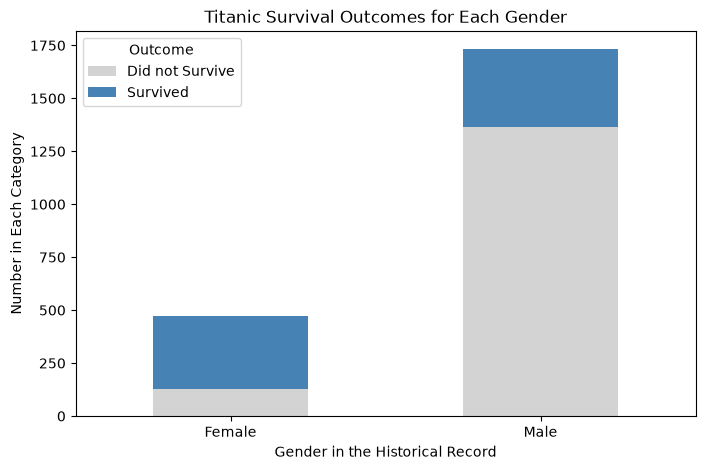

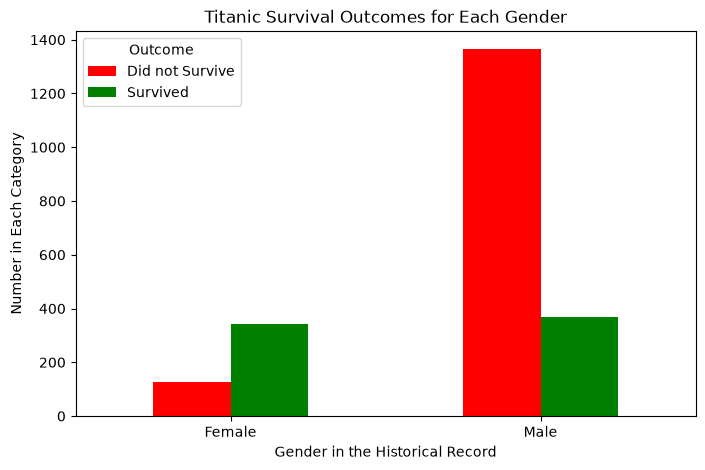

In [20]:
pd.crosstab(titanic_df['sex'], titanic_df['survived']).plot(
    kind="bar",
    stacked=True,
    color=["lightgray", "steelblue"],
    figsize=(8, 5)
)

plt.title("Titanic Survival Outcomes for Each Gender")
plt.xlabel("Gender in the Historical Record")
plt.ylabel("Number in Each Category")
plt.xticks(rotation=0)
plt.legend(["Did not Survive", "Survived"], title="Outcome")
plt.show()

pd.crosstab(titanic_df['sex'], titanic_df['survived']).plot(
    kind="bar",
    color=["red", "green"],
    figsize=(8, 5)
)

plt.title("Titanic Survival Outcomes for Each Gender")
plt.xlabel("Gender in the Historical Record")
plt.ylabel("Number in Each Category")
plt.xticks(rotation=0)
plt.legend(["Did not Survive", "Survived"], title="Outcome")
plt.show()


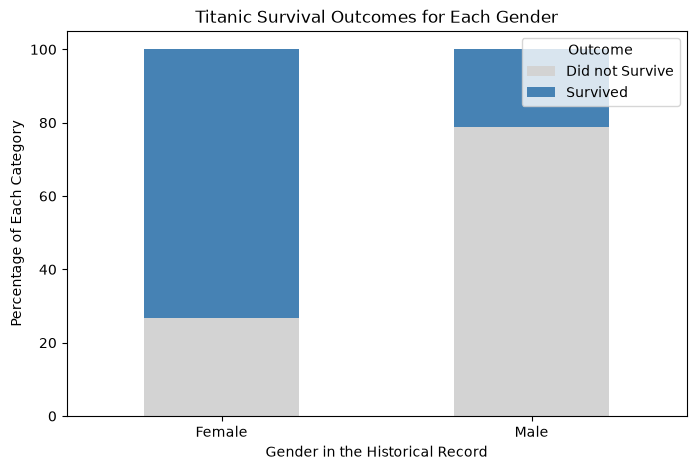

In [21]:
pd.crosstab(titanic_df['sex'], titanic_df['survived'], normalize='index').mul(100).plot(
    kind="bar",
    stacked=True,
    color=["lightgray", "steelblue"],
    figsize=(8, 5)
)

plt.title("Titanic Survival Outcomes for Each Gender")
plt.xlabel("Gender in the Historical Record")
plt.ylabel("Percentage of Each Category")
plt.xticks(rotation=0)
plt.legend(["Did not Survive", "Survived"], title="Outcome")
plt.show()

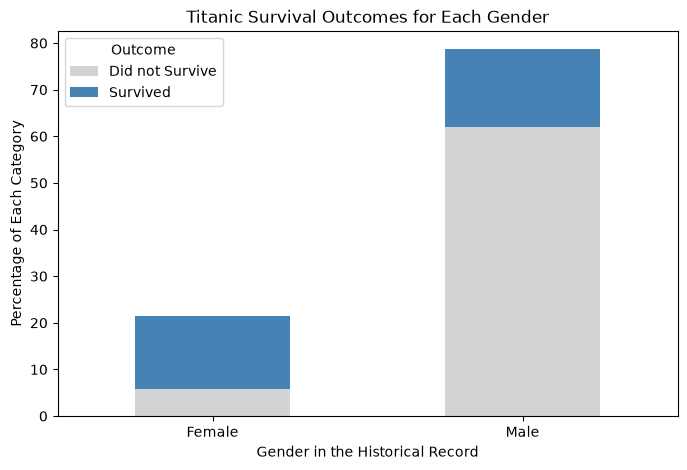

In [22]:
pd.crosstab(titanic_df['sex'], titanic_df['survived'], normalize='all').mul(100).plot(
    kind="bar",
    stacked=True,
    color=["lightgray", "steelblue"],
    figsize=(8, 5)
)

plt.title("Titanic Survival Outcomes for Each Gender")
plt.xlabel("Gender in the Historical Record")
plt.ylabel("Percentage of Each Category")
plt.xticks(rotation=0)
plt.legend(["Did not Survive", "Survived"], title="Outcome")
plt.show()

## Discussion: identify the evidence

1. Approximately what percentage of males survived?

2. Approximately what percentage of females survived?

3. Which comparison directly answers the research question?


## Steps 6 and 7 — Conclusion and limitation

**Evidence:** Although 367 males survived compared with 344 females, about 21.2% of males survived compared with about 73.2% of females.

**Conclusion:** Females aboard the Titanic were more likely to survive than males in this dataset.

**Limitation:** A familiar historical narrative attributes women's greater survival to “women and children first” and chivalry. That may be part of the story, but this two-feature comparison cannot show that it was the only explanation. Sex, age group, and passenger class or crew status were interrelated, and the historical records have known limitations.


## Discussion: what else might be related?

1. Were females more or less likely than males to be recorded as children?

2. Did females and males have the same distribution across passenger classes and the crew?

3. If age and class were also related to survival, why would those differences complicate a simple explanation based only on sex?


## Examine how sex, age, and class are interrelated

First compare the age-group distribution within each sex category.


In [23]:
pd.crosstab(titanic_df['age_group'], titanic_df['survived'], normalize='index')*100

survived,No,Yes
age_group,,
Adult,68.738050,31.261950
Child,47.706422,52.293578


In [24]:
pd.crosstab(titanic_df['class'], titanic_df['survived'], normalize='index')*100

survived,No,Yes
class,,
1st,37.538462,62.461538
2nd,58.596491,41.403509
3rd,74.787535,25.212465
Crew,76.045198,23.954802


Next compare passenger class and crew status within each sex category. The `class` feature includes the ship's crew as well as three passenger classes.


In [25]:
pd.crosstab(titanic_df['class'], titanic_df['sex'], normalize='index')*100

sex,Female,Male
class,,
1st,44.615385,55.384615
2nd,37.192982,62.807018
3rd,27.762040,72.237960
Crew,2.598870,97.401130


In [26]:
pd.crosstab(titanic_df['age_group'], titanic_df['sex'], normalize='index')*100

sex,Female,Male
age_group,,
Adult,20.315488,79.684512
Child,41.284404,58.715596


## Discussion: interpret the group composition

1. Which sex category had the greater percentage of children?

2. Which sex category had greater percentages in first and second class?

3. Which sex category was much more likely to be part of the crew?


## Put three categorical features in one chart

A 100% stacked bar chart can show survival outcomes within combinations of two grouping features. Here, each bar represents one combination of sex and age group, while the stacked colors represent survival.


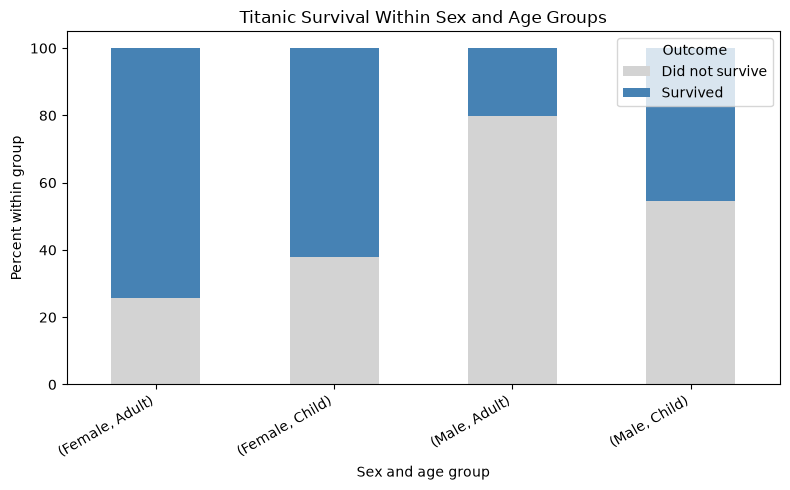

In [27]:
titanic = titanic_df

survival_by_sex_and_age = (
    pd.crosstab(
        [titanic["sex"], titanic["age_group"]],
        titanic["survived"],
        normalize="index"
    )
    * 100
)

survival_by_sex_and_age[["No", "Yes"]].plot(
    kind="bar",
    stacked=True,
    color=["lightgray", "steelblue"],
    figsize=(8, 5)
)

plt.title("Titanic Survival Within Sex and Age Groups")
plt.xlabel("Sex and age group")
plt.ylabel("Percent within group")
plt.xticks(rotation=30, ha="right")
plt.legend(["Did not survive", "Survived"], title="Outcome")
plt.tight_layout()
plt.show()


Now use the same design for sex and passenger class or crew status.


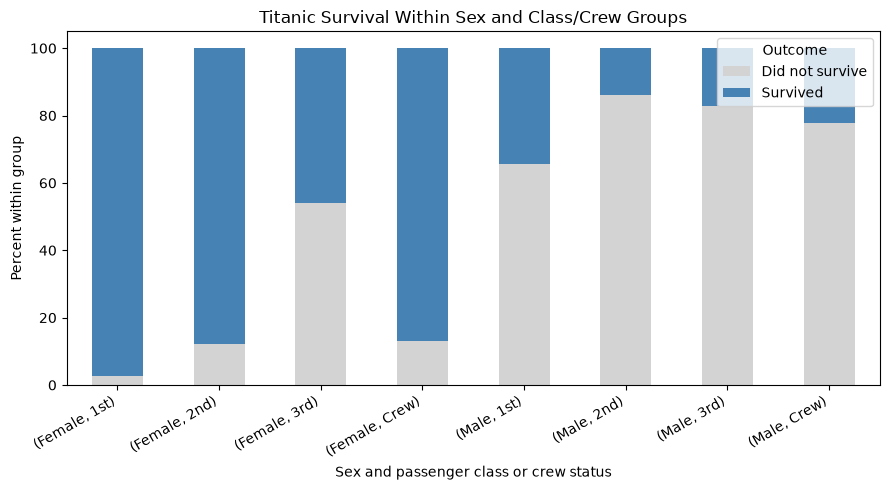

In [28]:
survival_by_sex_and_class = (
    pd.crosstab(
        [titanic["sex"], titanic["class"]],
        titanic["survived"],
        normalize="index"
    )
    * 100
)

survival_by_sex_and_class[["No", "Yes"]].plot(
    kind="bar",
    stacked=True,
    color=["lightgray", "steelblue"],
    figsize=(9, 5)
)

plt.title("Titanic Survival Within Sex and Class/Crew Groups")
plt.xlabel("Sex and passenger class or crew status")
plt.ylabel("Percent within group")
plt.xticks(rotation=30, ha="right")
plt.legend(["Did not survive", "Survived"], title="Outcome")
plt.tight_layout()
plt.show()


`plt.tight_layout()` is useful here because the multi-part category labels need more room than the earlier labels. It adjusts the spacing so the title, axes, and tick labels are less likely to be clipped.


## Discussion: what do the three-feature charts add?

1. Does the female survival percentage remain the same across age groups and classes?

2. Which comparison shows why a single overall female survival percentage cannot tell the entire story?

3. What can these charts reveal, and what causal claim can they still not establish?


## Compare the evidence figure with a raw-count chart


The default chart is correct, but we can refine its visual design so the question and categories are clearer.


## Refining the visual design

**Visual design** is the broad term for decisions about colors, labels, category order, spacing, titles, legends, and scales.

**Annotation** is narrower. It means adding explanatory information directly to a figure, such as a text label, arrow, note, or reference line. Changing a color is a visual-design or formatting decision, not an annotation.

Every design choice should help the audience understand the evidence rather than merely decorate the chart. The Step 5 figure uses:

- percentages to compare groups of different sizes;
- gray for the non-survival outcome and blue for survival;
- audience-friendly labels;
- a question-focused title;
- an explanatory legend; and
- a zero-to-100% scale created by the conditional distribution.


## Counts and percentages answer different questions

- The **count chart** shows how many people were recorded in each combination.
- The **100% stacked chart** shows survival composition within each sex category.

If total group size matters, show counts separately rather than expecting one figure to communicate both volume and composition.


# Part 2: A Balanced Mobile-Game A/B Test

An A/B test compares two versions of a product or experience. One version commonly serves as a control and another as a variation. Random assignment is intended to make the groups comparable before they experience the versions.

The Cookie Cats dataset compares:

- `gate_30`: the first progression gate appeared at level 30;
- `gate_40`: the first progression gate appeared at level 40.

We will describe the observed results; formal statistical inference comes later.


## Step 1 — Question

> **Which game version had greater observed seven-day retention?**

## Discussion: identify the features

1. Which feature is the target?

2. Which feature defines the groups being compared?

3. Why does the word “observed” matter in this question?


In [29]:
cookiecats_df = pd.read_csv('data/cookie_cats.csv')

cookiecats_df.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


## Step 2 — Data

### Cookie Cats data dictionary

| Feature | Feature type | Description |
| --- | --- | --- |
| `userid` | Identifier | Player identifier |
| `version` | Categorical | Assigned game version |
| `sum_gamerounds` | Quantitative | Number of game rounds played |
| `retention_1` | Categorical/Boolean | Whether the player returned after one day |
| `retention_7` | Categorical/Boolean | Whether the player returned after seven days |


In [30]:
cookiecats_df.tail()

,userid,version,sum_gamerounds,retention_1,retention_7
90184,9999441,gate_40,97,True,False
90185,9999479,gate_40,30,False,False
90186,9999710,gate_30,28,True,False
90187,9999768,gate_40,51,True,False
90188,9999861,gate_40,16,False,False


In [31]:
cookiecats_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   userid          90189 non-null  int64
 1   version         90189 non-null  str  
 2   sum_gamerounds  90189 non-null  int64
 3   retention_1     90189 non-null  bool 
 4   retention_7     90189 non-null  bool 
dtypes: bool(2), int64(2), str(1)
memory usage: 2.8 MB


In [32]:
cookiecats_df.isnull().sum()

userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64

Inspect the count and relative-frequency distributions of the comparison and target features.


In [33]:
cookiecats_df['version'].value_counts()

version
gate_40    45489
gate_30    44700
Name: count, dtype: int64

In [34]:
cookiecats_df['version'].value_counts(normalize=True)*100

version
gate_40    50.437415
gate_30    49.562585
Name: proportion, dtype: float64

In [35]:
cookiecats_df['retention_1'].value_counts()

retention_1
False    50036
True     40153
Name: count, dtype: int64

In [36]:
cookiecats_df['retention_1'].value_counts(normalize=True)*100

retention_1
False    55.47905
True     44.52095
Name: proportion, dtype: float64

In [37]:
cookiecats_df['retention_7'].value_counts()

retention_7
False    73408
True     16781
Name: count, dtype: int64

In [38]:
cookiecats_df['retention_7'].value_counts(normalize=True)*100

retention_7
False    81.393518
True     18.606482
Name: proportion, dtype: float64

## Discussion: inspect the experiment

1. Are the two version groups similar in size?

2. What percentage of all players returned after seven days?

3. Why does a roughly balanced assignment not imply a roughly 50/50 split in the outcome?


## Step 3 — Operation

Create the joint frequency table, then calculate the conditional distribution of retention within each game version.


In [39]:
pd.crosstab(cookiecats_df['version'], cookiecats_df['retention_1'])

retention_1,False,True
version,,
gate_30,24666,20034
gate_40,25370,20119


In [40]:
pd.crosstab(cookiecats_df['version'], cookiecats_df['retention_1'], normalize='index')

retention_1,False,True
version,,
gate_30,0.551812,0.448188
gate_40,0.557717,0.442283


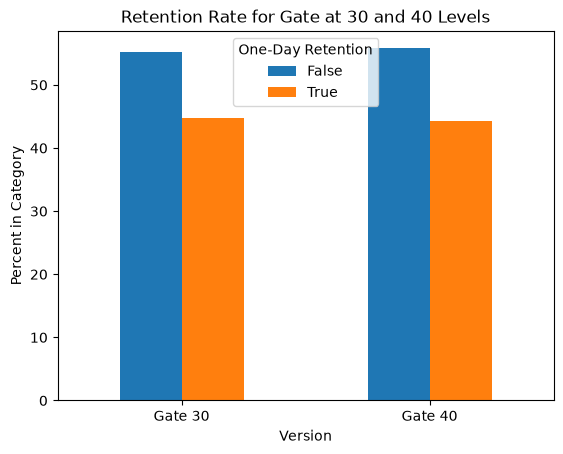

In [41]:
pd.crosstab(cookiecats_df['version'], cookiecats_df['retention_1'], normalize='index').mul(100).plot(
    kind='bar'
)

plt.title('Retention Rate for Gate at 30 and 40 Levels')
plt.ylabel('Percent in Category')
plt.xlabel('Version')
plt.xticks([0,1],['Gate 30', 'Gate 40'], rotation=0) # [0,1] is a positional argument that says which number tick to fill in
plt.legend(['False', 'True'], title='One-Day Retention', loc='upper center')
plt.show()

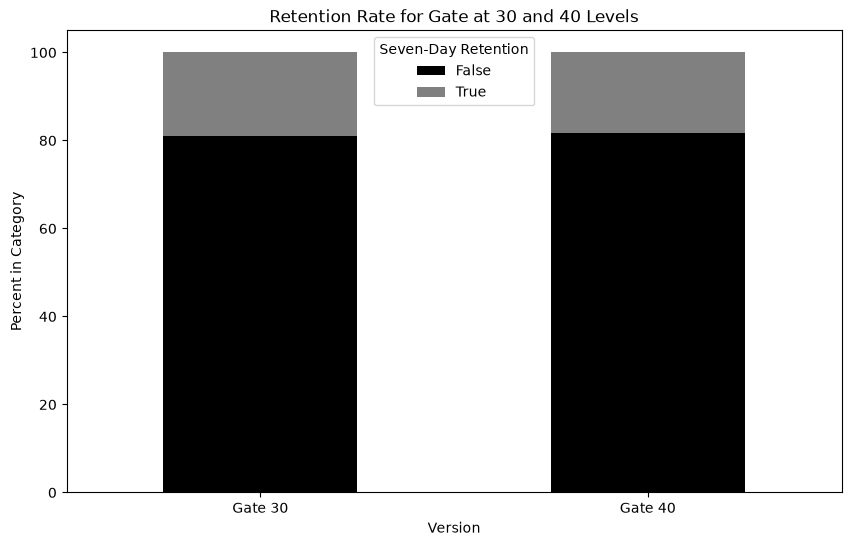

In [42]:
pd.crosstab(cookiecats_df['version'], cookiecats_df['retention_7'], normalize='index').mul(100).plot(
    kind='bar',
    stacked=True,
    color=['black', 'gray'],
    figsize=(10,6)
)

plt.title('Retention Rate for Gate at 30 and 40 Levels')
plt.ylabel('Percent in Category')
plt.xlabel('Version')
plt.xticks([0,1],['Gate 30', 'Gate 40'], rotation=0) # [0,1] is a positional argument that says which number tick to fill in
plt.legend(['False', 'True'], title='Seven-Day Retention', loc='upper center')
plt.show()

The counts show the joint distribution, but unequal group totals can still affect them. Use row normalization because the question asks about retention **within each version**.


## Step 4 — Check

Confirm that the two conditional rows add to 100%.


## Discussion: check the result

1. Did each row add to 100%?

2. What does one complete row represent?


## Step 5 — Evidence

Select the `True` column so the figure focuses on the percentage retained after seven days.


In [45]:
retained_after_7_days = pd.crosstab(cookiecats_df['version'], cookiecats_df['retention_7'], normalize='index').mul(100)

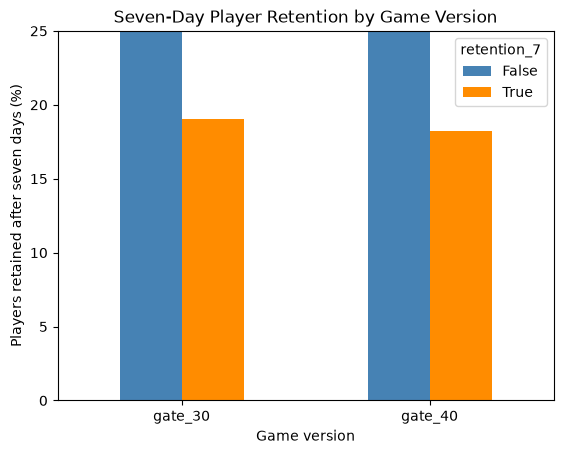

In [46]:
retained_after_7_days.plot(
    kind="bar",
    color=["steelblue", "darkorange"],
    ylim=(0, 25)
)

plt.title("Seven-Day Player Retention by Game Version")
plt.xlabel("Game version")
plt.ylabel("Players retained after seven days (%)")
plt.xticks(rotation=0)
plt.show()


The y-axis begins at zero. Because bar length represents magnitude, a truncated axis could exaggerate the small difference.


## Discussion: identify the evidence

1. Which version had greater observed seven-day retention?

2. How large does the difference appear?


## Step 6 — Conclusion

**Conclusion:** In this dataset, the gate-at-level-30 group had slightly greater observed seven-day retention than the gate-at-level-40 group.


## Step 7 — Limitation

The descriptive comparison does not tell us whether the difference is larger than expected from random variation. Confidence intervals or an inferential test would be needed before treating the observed difference as a reliable treatment effect.

## Discussion: distinguish description from inference

1. Does random assignment make the observed comparison meaningful?

2. Is the chart alone enough to conclude that moving the gate caused a reliable retention difference?


## Procedure for comparing categorical features

1. State the question and identify any target feature.
2. Inspect both feature frequencies.
3. Create a count cross-tab.
4. Check group totals.
5. Identify the denominator implied by the question.
6. Calculate the joint or row-conditional relative frequencies required by the question.
7. Check that the expected percentages add to 100%.
8. Choose an appropriate chart.
9. Refine its visual design to clarify the evidence.
10. State a conclusion and limitation.


## Discussion

1. Why can the group with the largest number of target outcomes differ from the group with the largest target percentage?
2. How does the wording of a question determine whether each row or the entire table should add to 100%?
3. What additional evidence would be needed before claiming that changing the game gate caused a retention difference?


## Key takeaways

- A target feature is the outcome a model is intended to predict.
- Counts describe combinations of categories.
- Joint percentages describe combinations relative to the full dataset.
- Conditional percentages describe one feature within another.
- `normalize="index"` makes rows add to 100%.
- Visual design includes colors, titles, labels, legends, ordering, and scales.
- Annotation specifically adds explanatory text or markers to a figure.
- An observed relationship does not automatically explain its cause.


# Optional historical interlude: Early innovators in data visualization

This section is optional. It introduces two people whose work helped establish visual methods that are still recognizable today.

Charts can seem like natural ways to display data, but their conventions had to be invented. Early chart makers had to decide how position, length, area, color, and direction could represent quantities and relationships.


## William Playfair and new ways to compare quantities

William Playfair (1759–1823) was a Scottish engineer and political economist. He is generally credited with publishing:

- the first bar chart in *The Commercial and Political Atlas* in 1786; and
- the first pie chart in *The Statistical Breviary* in 1801.

Playfair used charts to make economic comparisons easier to see than they were in a table of numbers. The examples below show how he used bar length to compare trade values and divided a circle to show parts of a whole.


<img src="images/playfair_bar_chart_1786.jpg" alt="William Playfair's 1786 bar chart comparing Scotland's exports and imports" width="760">

*Playfair's 1786 comparison of Scotland's exports and imports. Bar length represents value. [Original image from Wikimedia Commons](https://commons.wikimedia.org/wiki/File:1786_Playfair_-_Exports_and_Imports_of_Scotland_to_and_from_different_parts_for_one_Year_from_Christmas_1780_to_Christmas_1781.jpg), public domain.*


<img src="images/playfair_pie_chart_1801.jpg" alt="William Playfair's 1801 pie chart comparing the populations and geographic areas of nations" width="440">

*Playfair's 1801 chart comparing the populations and geographic areas of nations. [Original image from Wikimedia Commons](https://commons.wikimedia.org/wiki/File:Playfair-piechart.jpg), public domain.*


**Consider:**

- Which visual encodings in these figures are still used in bar charts and pie charts?
- What parts of the figures would you redesign for a contemporary audience?


## Charles Joseph Minard and the flow map

Charles Joseph Minard (1781–1870) was a French civil engineer who pioneered the use of flow maps. His best-known visualization, published in 1869, depicts the losses suffered by Napoleon's army during the 1812 campaign in Russia.

Minard combined several features in one figure:

- geographic location and the army's direction of travel;
- the number of troops, represented by the width of the band;
- the advance toward Moscow in tan and the retreat in black; and
- dates and temperatures during the retreat.

The narrowing bands make the army's losses visible without requiring the reader to inspect every printed number.


<img src="images/minard_napoleon_1869.png" alt="Charles Joseph Minard's 1869 flow map of Napoleon's 1812 campaign in Russia" width="920">

*Minard's 1869 flow map of Napoleon's 1812 Russian campaign. [Original image from Wikimedia Commons](https://commons.wikimedia.org/wiki/File:Minard.png), public domain.*


<img src='https://upload.wikimedia.org/wikipedia/commons/5/5d/Minard_map_of_napoleon.png?utm_source=commons.wikimedia.org&utm_campaign=index&utm_content=original' alt="Charles Joseph Minard's 1869 flow map of Napoleon's 1812 campaign in Russia">

### Is Minard's map a Sankey diagram?

Minard's visualization is most precisely described as a **flow map** because the bands follow movement through geographic space. Its use of band width to represent quantity makes it an important precursor to the modern Sankey diagram.

The **Sankey diagram** is named for Irish engineer Matthew Henry Phineas Riall Sankey, who published an energy-flow diagram in 1898, almost three decades after Minard's famous map. A Sankey diagram shows quantities flowing between stages or categories, but it does not need to follow a geographic route.


**Consider:**

- What question does Minard's visualization help answer?
- Which feature is represented by the width of the band?
- What conclusion becomes visible as the band narrows?
- What information or limitations would you want to know before using the figure as historical evidence?


## Connecting these examples to the analysis workflow

Playfair and Minard did not have Pandas or Matplotlib, but their work still reflects familiar analytical decisions:

1. begin with a question;
2. select relevant data;
3. choose visual encodings that match the data;
4. make the evidence easier to compare; and
5. avoid claiming more than the available data can support.

Their charts also remind us that every visualization is designed. Even familiar choices such as bar length, circle area, band width, color, and scale influence what an audience notices.

**Further reading:** [Library of Congress on William Playfair](https://blogs.loc.gov/inside_adams/2026/04/william-playfair/) and [Library of Congress on Minard's flow maps](https://blogs.loc.gov/maps/2021/06/19th-century-colonization-and-slavery-in-charles-minards-flow-maps/).
